# TP5  POD + EIM

In [ ]:
#Install package
import sys
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install scikit-fem

In [14]:
# import packages

import skfem  # for Finite Element Method
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import random
from scipy.sparse.linalg import factorized
import time

 ============================================================
 
## Greedy-Galerkin with FEM
###  Poisson equation  / thermal stationary conduction

 Elliptic diffusion problem (2D) with scikit-fem:
 
   $ -\nabla \cdot ( A(x,\mu) \nabla u) = g(x)  \ \mathrm{ on }\ (0, 1)^2$ 
   
$    u(0) = u(1) = 0  (Dirichlet)$

-------------------
    
    FEM:
 
 Find $u_h = \sum_{i=1}^{\mathcal{N}} u_i w_i$ such that :

   $a(u_h,v_h;\mu)=l(v_h), \ \forall v_h \in V_h$

 with Dirichlet boundary $u=0$ on $\partial \Omega$.

 Here $\Omega=[0,1] \times [0,1] = \Omega_1 \cup \Omega_2 \cup \Omega_3 \cup \Omega_4$. We use a uniform Delaunay mesh, with $Nx \times Ny$ degrees of freedom.
 
$A(x,\mu)= \frac{1}{(x_1-\mu_1)^2+ (x_2-\mu_2)^2} $  in $ \Omega_i$

with $\mu_i \in [-2,-1]$ 


$g=1$

--------
#### 1) Complete the code and solve the problem for mu =[1,2,3,4]

Time : 0.010053157806396484 secondes


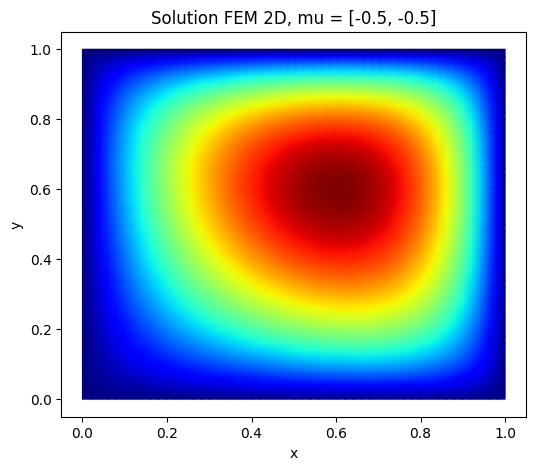

In [15]:
"""
Elliptic diffusion problem (2D) with scikit-fem:

$ -\nabla \cdot ( A(x,\mu) \nabla u) = g(x)  \ \mathrm{ on }\ (0, 1)^2$ 
$    u(0) = u(1) = 0  (Dirichlet)$

"""

import numpy as np
import matplotlib.pyplot as plt

from skfem import MeshTri, Basis, asm, enforce,solve
from skfem.element import ElementTriP1
from skfem.helpers import dot, grad
from skfem.assembly import BilinearForm, LinearForm
from skfem import solve

# -----------------------
# Problem setup
# -----------------------

Nx = 50
Ny = 50

# Maillage triangulaire du carré (0,1)^2
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)

basis = Basis(m, ElementTriP1())

# Dirichlet boundary DOFs 
D = basis.get_dofs().all()  # all dofs

# l2 scalar product in 2D
@BilinearForm
def massMatrix(u, v, _):
    return ...


# -----------------------
# RHS: g = 1
# -----------------------
@LinearForm
def rhs(v, w):
    return ...

# -----------------------
# Bilinear form
# -----------------------
@BilinearForm
def diffusion(u, v, w):
    return  ...
    
@BilinearForm
def diffusion_mu(u, v, w):
    ...
    return ...



# -----------------------
# Assembly
# -----------------------
def FEMassembling(m,mu):
    basis = Basis(m, ElementTriP1())
    A11 = asm(diffusion_mu, basis,mu1=mu[0],mu2=mu[1])   # on Omega_11    
    b = asm(rhs, basis)                #  g = 1
    
    return A11, b, basis


# -----------------------
# Solve
# -----------------------
def FEMsolve(A11, b, basis, mu):
    
    A_bc, b_bc = enforce(A11, b, D=basis.get_dofs().all()) # Dirichlet 
    u = solve(A_bc, b_bc) #solve
    
    return u



# -----------------------
# Example
# -----------------------
mu =[-0.5,-0.5]
A11, b, basis = FEMassembling(m,mu)
                                                                                                                   
start = time.time()                                                                                                             
                                                                                                    
u = FEMsolve(A11, b, basis, mu)
end = time.time()  
print("Time :", end - start, "secondes")

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6, 5))
m.plot(u, ax=ax, shading='gouraud')
ax.set_title(f"Solution FEM 2D, mu = {mu}")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

In [18]:
############
""" POD """
############ 

def Construct_RB(NumberOfSnapshots=100,NumberOfModes=20,m=m):
    ...
    # orthogonality test
    return ReducedBasis

eigenvalues:  [2.33547231e+01 2.35622158e-03 1.69859839e-03 1.10159535e-07
 4.52355318e-09 1.03259991e-09]


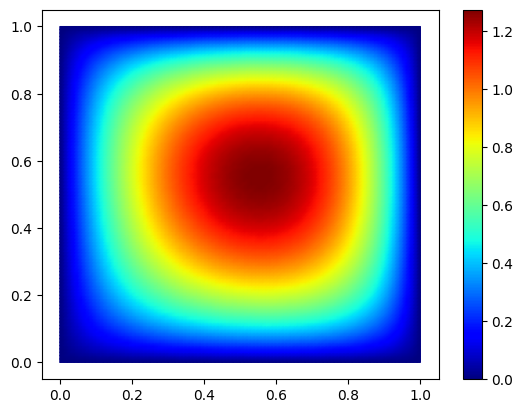

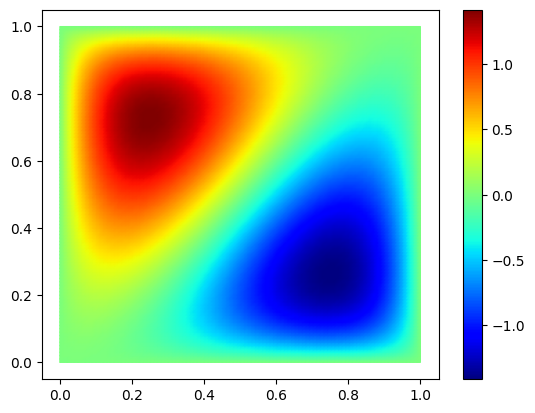

In [20]:
Nx=Ny = 100
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)

Phi=Construct_RB(NumberOfSnapshots=100,NumberOfModes=6,m=m)
ReducedBasis=Phi.T              

fig, ax = plt.subplots()

im=m.plot(ReducedBasis[:,0], ax=ax, shading='gouraud',colorbar=True)
fig, ax = plt.subplots()

m.plot(ReducedBasis[:,1], ax=ax, shading='gouraud',colorbar=True)

plt.show()

In [27]:

def solve_fem_rom(mu, Phi,m):
    ...
    return u_rom

eigenvalues:  [2.35781631e+01 2.66412052e-03 1.98265280e-03 1.00231404e-07
 4.47211962e-09 1.30141639e-09]
Time : 0.03787684440612793 secondes


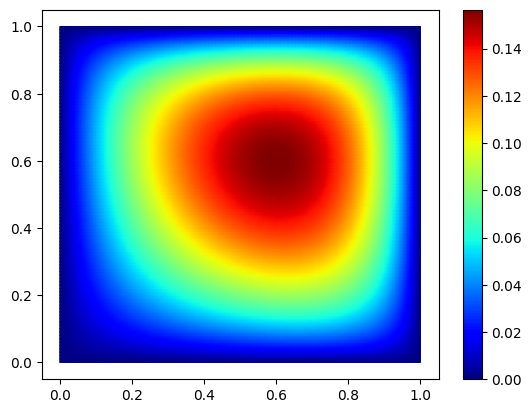

In [28]:
mu = (-0.5,-0.5)
Nx=Ny = 100
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)
basis = Basis(m, ElementTriP1())

A11, b, basis = FEMassembling(m,mu)
Phi=Construct_RB(NumberOfSnapshots=100,NumberOfModes=6,m=m)                                                                                 
start = time.time()                                                                                                             
                                                                                                        
u_proj=solve_fem_rom(mu, Phi,m)
end = time.time()                                                                                                            
print("Time :", end - start, "secondes")
fig, ax = plt.subplots()

m.plot(u_proj, ax=ax, shading='gouraud',colorbar=True)



plt.show()

## EIM

#### 2. Complete the code EIM 

In [ ]:

from skfem import Basis, ElementTriP0

# ============================================================
# Param
# ============================================================

NumberOfModes = ...
NumberOfSnapshots = ...

MuMin = -2.0
MuMax = -1.0

basis = Basis(m, ElementTriP0())   # P0 : one value for each element 
dof_locs = basis.doflocs            
ndof = dof_locs.shape[1]

# training set 
mu1_train = ...
mu2_train = ...

# ============================================================
# Function g(x; mu1, mu2)
# ============================================================

def g_fun(x, mu1, mu2):
    return ...

def project_g(mu1, mu2):
    """
    Projection/interpolation of g on FEM P0.
    """
    return basis.project(lambda x: g_fun(x, mu1, mu2))

# ============================================================
# OFFLINE : initialization
# ============================================================

#  snapshots g(mu)
ntrain = NumberOfSnapshots * NumberOfSnapshots

GGrid = np.zeros((ndof, ntrain))
GinftyGrid = np.zeros(ntrain)
mu_pairs = []

col = 0
for a in mu1_train:
    for b in mu2_train:
        u = ... # g projected 
        GGrid[:, col] = u
        GinftyGrid[col] = ... # norm inf of u
        mu_pairs.append((a, b))
        col += 1

# first parameter
muIndex = ...
muIndexlist = [...]

mu1_star, mu2_star = ...
g1 = ...# first u(:,mu) 

# first magic point
XIndex = ...
MagicPointIndiceslist = [...]
MagicPointlist = [(dof_locs[0, XIndex], dof_locs[1, XIndex])]

print("First magic point :", MagicPointlist[0])

# FIRST BASIS EIM
q1 = ...
qlist = [...]

# ============================================================
# OFFLINE :  EIM iterations
# ============================================================

for M in range(1, NumberOfModes):
    print(f"M = {M}")

    # Triangular matrix Q_M
    Qmat = ...
    for i in range(M):
        for j in range(M):
            Qmat[i, j] = ...

    ResidualGrid = np.zeros((ndof, ntrain))
    ResidualInf = np.zeros(ntrain)

    # Residual for each training parameters
    for col, (a, b) in enumerate(mu_pairs):
        u = ...

        Gvec = ... # right hand side
        alpha= ... # coefficients
        residual =...
        for i in range(M):
            residual -= ...

        ResidualGrid[:, col] = ... 
        
        ResidualInf[col] = ... 

    # avoir already chosen parameter
    for old_idx in muIndexlist:
        ResidualInf[old_idx] = -1e30

    # new optimal parameter
    muIndex =...
    
    muIndexlist.append(...)

    mu1_star, mu2_star = ...
    gM = ...

    # avoid already chosen point

    scores = np.abs(gM)
    for old_x in MagicPointIndiceslist:
        scores[old_x] = -np.inf
    # new magic point
 
    XIndex = ...

    MagicPointIndiceslist.append(...)
    MagicPointlist.append((dof_locs[0, XIndex], dof_locs[1, XIndex]))

    print("New magic point :", MagicPointlist[-1])
    print("Selected parameter :", (mu1_star, mu2_star))

    #basis function
    qM = ...
    qlist.append(...)

# ============================================================
# ONLINE
# ============================================================

mu1_target = ...
mu2_target = ...

u_true = project_g(mu1_target, mu2_target)

# complete Q
Qmat = ...
for i in range(NumberOfModes):
    for j in range(i + 1):   
        Qmat[i, j] = ...

Gvec = ...

# coefficients EIM
alpha = ...

# reconstruction EIM
u_eim = ...
for j in range(NumberOfModes):
    u_eim += ...

# ============================================================
# Test in one point (xseek, yseek)
# ============================================================

xseek, yseek = 0.5, 0.5

element_finder = m.element_finder()
element_index = element_finder(np.array([xseek]), np.array([yseek]))[0]

approx_value = u_eim[element_index]
true_value_fem = u_true[element_index]
true_value_exact = g_fun(np.array([[xseek], [yseek]]), mu1_target, mu2_target)[0]

print()
print(f"Tested point : ({xseek}, {yseek})")
print(f"Approximation EIM      : {approx_value}")
print(f"Projeted FEM    : {true_value_fem}")
print(f"Exact value g(x, mu) : {true_value_exact}")
print(f"Error |EIM - FEM|     : {abs(approx_value - true_value_fem)}")
print(f"Error |EIM - exact|  : {abs(approx_value - true_value_exact)}")

#### 3. Change your previous code to obtain one OFFLINE EIM and one ONLINE EIM and test it with your FEM + Reduced Basis Method code

In [ ]:



def build_eim_offline(
    mesh,
    number_of_modes=15,
    number_of_snapshots=20,
    mu_min=-2.0,
    mu_max=-1.0,
):
  ...

    return {
        "q_basis": q_basis,
        "magic_indices": magic_indices,
        "magic_points": magic_points,
        "Q": Q,
        "basis_coeff": basis_coeff,
        "mu_pairs": mu_pairs,
    }

In [56]:
def eim_online(mu1, mu2, eim_data):
    """
    Compute theta(mu) such that
        g(x;mu) ≈ sum_m theta_m(mu) q_m(x)
    """
    ...

    return theta